In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy

import pyccl as ccl

import treecorr

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 16,          # base font size
    "axes.labelsize": 18,     # x and y labels
    "axes.titlesize": 18,     # title
    "legend.fontsize": 14,    # legend
    "xtick.labelsize": 14,    # x tick labels
    "ytick.labelsize": 14,    # y tick labels
})


import sys
import os
import copy

sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code")) 

In [2]:
from halo_model.power_spectra.matter_power_baryons import MatterPowerBaryons
from halo_model.halos.base.profile.profile import CompositeProfile

from halo_model.config.config import Config
from halo_model.algorithms.ridders_derivative import ridders_derivative

from halo_model.power_spectra.xi_computer import compute_Pk_2d, Pk_2d_to_Cl, Cl_to_xi, compute_xi, covariance_xi
from halo_model.power_spectra.del_xi import del_xi

sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code/plotting_code/constraining_power")) 

In [3]:
# set config 
cfg = Config()

In [ ]:

# # Compute derivative for each theta angle

params = [
    # WDM parameters
    ['logM0', 1],
    # ['beta', 0.2],
    ['logm0', 1],
    
    # concentration clumps
    ['Q', 0.4],
    
    # concentratiion distribution
    ['D', 0.4],   
    
    # gas profile
    ['logM_c', 1],
    ['theta_ej', 2],
    ['gamma', 0.8],
    ['delta', 3],
    ['mu', 0.2],
    ['logM_gaslimit', 2], 
    
    # stellar profile
    ['r_star', 0.005],
    ['S', 0.4],
]

for param in params:
    name, h_init = param
    fname = f'derivs_{name}.npy'
    if os.path.exists(fname):
        print(f"Skipping {name}, {fname} already exists")
        continue
    print("Computing derivatives of parameter ", name)
    derivs = del_xi(cfg=cfg, param=name, h_init=h_init, n_iters=4)
    np.save(fname, derivs)



Computing derivatives of parameter  logM0
computing the 0th pair for Ridders


/home/milan/.local/lib/python3.10/site-packages/mcfit/mcfit.py:130: UserWarning: use backend='jax' if desired
  warnings.warn("use backend='jax' if desired")


computing power spectrum at redshift 2.0


In [ ]:


derivs_beta = np.load("derivs_beta.npy")
derivs_theta_ej = np.load("derivs_theta_ej.npy")
derivs_delta = np.load("derivs_delta.npy")
derivs_gamma = np.load("derivs_gamma.npy")
derivs_Q = np.load("derivs_Q.npy")
derivs_r_h = np.load("derivs_r_h.npy")

# print(derivs_beta)
# print(derivs_theta_ej)

# D = np.vstack(
#     [
#     derivs_beta,
#     derivs_theta_ej,
#     # derivs_delta,
#     # derivs_gamma,
#     # derivs_Q,
#     ]
# )

# np.save("deriv_arr", D)

In [ ]:
cov = covariance_xi(cfg)
Cinv = np.linalg.inv(cov)


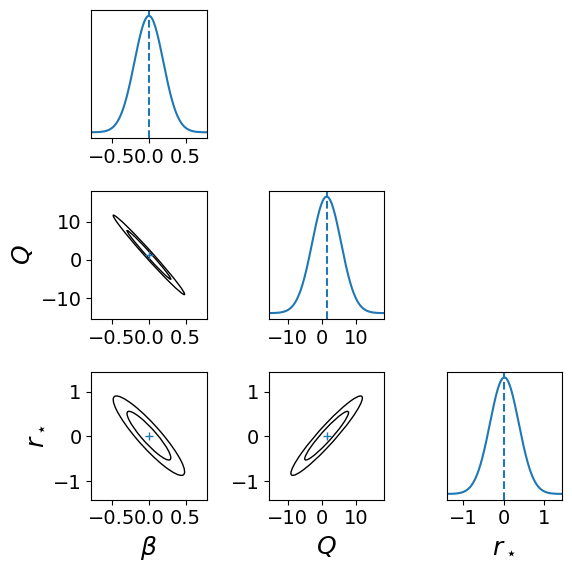

In [ ]:
from fisher_corner import fisher_corner

D = np.vstack(
    [
    derivs_beta,
    # derivs_theta_ej,
    # derivs_delta,
    # derivs_gamma,
    derivs_Q,
    derivs_r_h,
    ]
)

F = D @ Cinv @ D.T

fiducial = [
    cfg.beta,
    # cfg.theta_ej,
    # cfg.delta,
    # cfg.gamma,
    cfg.Q,
    cfg.r_star,
]

labels = [
    r"$\beta$", 
    # r"$\theta_{\mathrm{eject}}$", 
    # r"$\delta$", 
    # r"$\gamma$", 
    r"$Q$",
    r"$r_\star$",
]

limits = [
    None,#[-1,1], 
    # None,#[5, 7], 
    # None,#[4, 10], 
    # None,#[1, 3], 
    None,#[0, 5],
    None,#[0, 0.02],
]

fig = fisher_corner(
    F,
    fiducial,
    limits,
    labels=labels
)

plt.show()